In [1]:
!python3.9 -m pip install matplotlib

     |████████████████████████████████| 8.3 MB 9.4 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 37.4 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 20.4 MB/s eta 0:00:011
     |████████████████████████████████| 19.5 MB 24.1 MB/s eta 0:00:01
     |████████████████████████████████| 4.8 MB 25.2 MB/s eta 0:00:01
     |████████████████████████████████| 229 kB 18.1 MB/s eta 0:00:01
     |████████████████████████████████| 7.6 MB 25.6 MB/s eta 0:00:01�▉              | 4.2 MB 25.6 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 34.1 MB/s eta 0:00:01
     |████████████████████████████████| 321 kB 38.8 MB/s eta 0:00:01


In [2]:
!python3.9 -m pip install nilearn

     |████████████████████████████████| 12.7 MB 9.1 MB/s eta 0:00:01
     |████████████████████████████████| 12.8 MB 46.1 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 26.4 MB/s eta 0:00:01
     |████████████████████████████████| 5.2 MB 22.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.3 MB 21.1 MB/s eta 0:00:01
     |████████████████████████████████| 38.6 MB 21.9 MB/s eta 0:00:01
     |████████████████████████████████| 13.5 MB 35.9 MB/s eta 0:00:01
     |████████████████████████████████| 44 kB 10.2 MB/s eta 0:00:01
     |████████████████████████████████| 509 kB 38.8 MB/s eta 0:00:01
     |████████████████████████████████| 347 kB 24.6 MB/s eta 0:00:01


In [3]:
!python3.9 -m pip install seaborn

     |████████████████████████████████| 294 kB 8.5 MB/s eta 0:00:01


In [4]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 39.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nilearn.image as niimg
import nilearn.plotting as niplt
import os
from nilearn.image import resample_to_img
from nilearn import datasets
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [3]:
path = '/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/registration_fsl/'
participants = ["118528"]
# "131823","135124","118528"
fwhm_values = [5, 8]
hrf_derivatives = {"no": "no_derivatives","yes": "derivatives"}
nb_param_values = [0, 6, 24]
task = 'MOTOR'
contrasts = [1,2,3,4,5]

filename_template = (
    path +
    "_contrast_{contrast}_fwhm_{fwhm}_hrf_{hrf_full}_nb_param_{nb_param}_subject_id_{subject}_task_{task}" +
    "/_warpall_stat0/tstat{contrast}_warp.nii.gz"
)

loaded = {}

data_arrays = {}

for subj in participants:
    subj_key = f"s{subj}"
    loaded[subj_key] = {}
    data_arrays[subj_key] = {}
    
    for fwhm in fwhm_values:
        for hrf_short, hrf_full in hrf_derivatives.items():
            for nb_param in nb_param_values:

                pipeline_name = f"{subj_key}_fwhm{fwhm}_hrf{hrf_short}_param{nb_param}"
                loaded[subj_key][pipeline_name] = {}
                data_arrays[subj_key][pipeline_name] = {}

                for contrast in contrasts:

                    filename = filename_template.format(
                        subject=subj,
                        fwhm=fwhm,
                        hrf_full=hrf_full,
                        nb_param=nb_param,
                        task=task,
                        contrast=contrast
                    )

                    if not os.path.exists(filename):
                        print(f"Missing: {filename}")
                        continue
                        
                    img = niimg.load_img(filename)

                    loaded[subj_key][pipeline_name][contrast] = img
                    data_arrays[subj_key][pipeline_name][contrast] = img.get_fdata()

                    print(f"Loaded: {pipeline_name}_contrast{contrast}")


Loaded: s118528_fwhm5_hrfno_param0_contrast1
Loaded: s118528_fwhm5_hrfno_param0_contrast2
Loaded: s118528_fwhm5_hrfno_param0_contrast3
Loaded: s118528_fwhm5_hrfno_param0_contrast4
Loaded: s118528_fwhm5_hrfno_param0_contrast5
Loaded: s118528_fwhm5_hrfno_param6_contrast1
Loaded: s118528_fwhm5_hrfno_param6_contrast2
Loaded: s118528_fwhm5_hrfno_param6_contrast3
Loaded: s118528_fwhm5_hrfno_param6_contrast4
Loaded: s118528_fwhm5_hrfno_param6_contrast5
Loaded: s118528_fwhm5_hrfno_param24_contrast1
Loaded: s118528_fwhm5_hrfno_param24_contrast2
Loaded: s118528_fwhm5_hrfno_param24_contrast3
Loaded: s118528_fwhm5_hrfno_param24_contrast4
Loaded: s118528_fwhm5_hrfno_param24_contrast5
Loaded: s118528_fwhm5_hrfyes_param0_contrast1
Loaded: s118528_fwhm5_hrfyes_param0_contrast2
Loaded: s118528_fwhm5_hrfyes_param0_contrast3
Loaded: s118528_fwhm5_hrfyes_param0_contrast4
Loaded: s118528_fwhm5_hrfyes_param0_contrast5
Loaded: s118528_fwhm5_hrfyes_param6_contrast1
Loaded: s118528_fwhm5_hrfyes_param6_contrast

In [5]:
arr = data_arrays["s118528"]["s118528_fwhm5_hrfno_param6"][1]
arr.shape

(91, 109, 91)

In [6]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas.maps
atlas_img.shape

(91, 109, 91)

In [7]:
roi_labels = atlas.labels[1:]
roi_indices = range(1, len(roi_labels) + 1)
roi_labels_dict = {idx: label for idx, label in zip(roi_indices, roi_labels)}
roi_labels_dict

{1: 'Frontal Pole',
 2: 'Insular Cortex',
 3: 'Superior Frontal Gyrus',
 4: 'Middle Frontal Gyrus',
 5: 'Inferior Frontal Gyrus, pars triangularis',
 6: 'Inferior Frontal Gyrus, pars opercularis',
 7: 'Precentral Gyrus',
 8: 'Temporal Pole',
 9: 'Superior Temporal Gyrus, anterior division',
 10: 'Superior Temporal Gyrus, posterior division',
 11: 'Middle Temporal Gyrus, anterior division',
 12: 'Middle Temporal Gyrus, posterior division',
 13: 'Middle Temporal Gyrus, temporooccipital part',
 14: 'Inferior Temporal Gyrus, anterior division',
 15: 'Inferior Temporal Gyrus, posterior division',
 16: 'Inferior Temporal Gyrus, temporooccipital part',
 17: 'Postcentral Gyrus',
 18: 'Superior Parietal Lobule',
 19: 'Supramarginal Gyrus, anterior division',
 20: 'Supramarginal Gyrus, posterior division',
 21: 'Angular Gyrus',
 22: 'Lateral Occipital Cortex, superior division',
 23: 'Lateral Occipital Cortex, inferior division',
 24: 'Intracalcarine Cortex',
 25: 'Frontal Medial Cortex',
 26: '

In [8]:
def parse_pipeline_name(pipeline_name):
    # example: "s116727_fwhm5_hrfno_param6"
    parts = pipeline_name.split("_")
    fwhm = int(parts[1].replace("fwhm",""))
    hrf = 0 if "hrfno" in parts[2] else 1
    motion_reg = int(parts[3].replace("param",""))
    return fwhm, hrf, motion_reg

In [9]:
rows = []
roi_data = {roi_idx: [] for roi_idx in range(1, len(roi_labels) + 1)}

for subj in participants:
    subj_key = f"s{subj}"

    atlas_arr = atlas_img.get_fdata().astype(int)
    atlas_flat = atlas_arr.flatten()

    for pipeline in data_arrays[subj_key]:
        fwhm, hrf, motion_reg = parse_pipeline_name(pipeline)

        for contrast in data_arrays[subj_key][pipeline]:

            data_flat = data_arrays[subj_key][pipeline][contrast].flatten()

            n_vox = len(data_flat)

            # Create rows
            for voxel_index in range(n_vox):
                roi_idx = atlas_flat[voxel_index]  
                if roi_idx != 0: 
                    roi_data[roi_idx].append({
                        "voxel": voxel_index,
                        "roi": roi_idx,
                        "subj_id": subj,
                        "tvalue": float(data_flat[voxel_index]),
                        "fwhm": int(fwhm),
                        "motion_reg": int(motion_reg),
                        "hrf": int(hrf),
                        "contrast": int(contrast)
    })

In [10]:
roi_dfs = {
    f"roi_{roi_idx}": pd.DataFrame(rows)
    for roi_idx, rows in roi_data.items()
}

In [11]:
roi_dfs["roi_1"].head()

,voxel,roi,subj_id,tvalue,fwhm,motion_reg,hrf,contrast
0,185947,1,118528,-5.039628,5,0,0,1
1,185948,1,118528,-4.857032,5,0,0,1
2,185949,1,118528,-3.601366,5,0,0,1
3,186036,1,118528,-2.842743,5,0,0,1
4,186037,1,118528,-4.011854,5,0,0,1


In [12]:
#test for 1 roi

df = roi_dfs["roi_1"].copy()

df["subj_id"] = df["subj_id"].astype(str)
                                   
model = smf.mixedlm(
    "tvalue ~ fwhm + motion_reg + hrf",
    data=df,
    groups=df["subj_id"],
    re_formula="1"
)
result = model.fit()

results_table = pd.DataFrame({
    "coef": result.fe_params,
    "t_value": result.tvalues,
    "p_value": result.pvalues
})

# Apply FDR correction (BH procedure)
pvals = results_table["p_value"].values
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

results_table["p_fdr"] = pvals_fdr
results_table["reject_fdr"] = reject

print(results_table)


                coef       t_value       p_value         p_fdr  reject_fdr
Group Var        NaN  5.677821e-07  9.999995e-01  9.999995e-01       False
Intercept   0.312509  1.131459e-01  9.099149e-01  9.999995e-01       False
fwhm        0.037493  1.963779e+01  7.352544e-86  3.676272e-85        True
hrf         0.082079  1.433013e+01  1.418492e-46  3.546230e-46        True
motion_reg -0.000922 -3.282987e+00  1.027133e-03  1.711889e-03        True


In [13]:
#fit for all ROIs and concatenate all results

all_results = []

for roi_name, df in roi_dfs.items():
    df = df.copy()
    df["subj_id"] = df["subj_id"].astype(str)
    
    model = smf.mixedlm(
        "tvalue ~ fwhm + motion_reg + hrf",
        data=df,
        groups=df["subj_id"],
        re_formula="1"
    )
    result = model.fit()
    
    results_table = pd.DataFrame({
        "coef": result.fe_params,
        "t_value": result.tvalues,
        "p_value": result.pvalues
    })
    
    # Apply FDR correction (BH procedure)
    pvals = results_table["p_value"].values
    reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    results_table["p_fdr"] = pvals_fdr
    results_table["reject_fdr"] = reject
    
    results_table = results_table.reset_index()
    results_table.rename(columns={"index": "predictor"}, inplace=True)
    results_table["roi"] = roi_name
    
    all_results.append(results_table)

results_table_all = pd.concat(all_results, ignore_index=True)

/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceW

In [14]:
results_table_all.iloc[:10,:]
#reject = True means successfully reject null 

,predictor,coef,t_value,p_value,p_fdr,reject_fdr,roi
0,Group Var,NaN,5.677821e-07,9.999995e-01,9.999995e-01,False,roi_1
1,Intercept,0.312509,1.131459e-01,9.099149e-01,9.999995e-01,False,roi_1
2,fwhm,0.037493,1.963779e+01,7.352544e-86,3.676272e-85,True,roi_1
3,hrf,0.082079,1.433013e+01,1.418492e-46,3.546230e-46,True,roi_1
4,motion_reg,-0.000922,-3.282987e+00,1.027133e-03,1.711889e-03,True,roi_1
5,Group Var,NaN,NaN,NaN,NaN,False,roi_2
6,Intercept,1.440711,4.845192e-01,6.280175e-01,NaN,False,roi_2
7,fwhm,0.059229,1.119840e+01,4.151605e-29,NaN,True,roi_2
8,hrf,0.150818,9.505016e+00,2.000173e-21,NaN,True,roi_2
9,motion_reg,-0.026041,-3.347387e+01,1.157219e-245,NaN,True,roi_2


In [14]:
results_table_all.groupby(by = ['predictor','reject_fdr']).count()

coef  t_value  p_value  p_fdr  roi
predictor  reject_fdr                                    
Group Var  False          0       20       20     20   48
Intercept  False         48       48       48     20   48
fwhm       False          3        3        3      0    3
           True          45       45       45     20   45
hrf        False         20       20       20      4   20
           True          28       28       28     16   28
motion_reg False         34       34       34     11   34
           True          14       14       14      9   14

/opt/miniconda-latest/envs/neuro/lib/python3.8/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


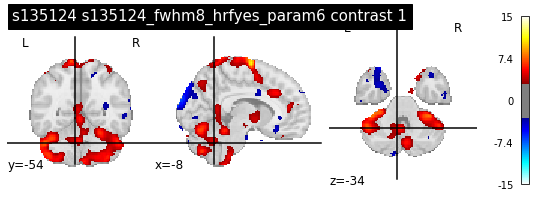

In [7]:
from nilearn import plotting

# subj_key = "s131823"
# pipeline_name = "s131823_fwhm8_hrfyes_param6"
subj_key = "s135124"
pipeline_name = "s135124_fwhm8_hrfyes_param6"
contrast = 1  # pick which contrast to plot

# Load the Nifti image
img = loaded[subj_key][pipeline_name][contrast]

# Plot it
plotting.plot_stat_map(
    img,
    threshold=3.0,
#     bg_img=None,
    display_mode='ortho',
    title=f"{subj_key} {pipeline_name} contrast {contrast}"
)
plotting.show()